# Init

In [1]:
import sympy  as sp

# Symxplorer Specific Imports
from   symxplorer.symbolic_exploration.domains   import ExperimentResult
from   symxplorer.designer_tools.visualizer      import Symbolic_Visualizer, Bode_Visualizer
from   symxplorer.designer_tools.symbolic_sizing import Symbolic_Sizing_Assist

s = sp.symbols("s")

# Load the exploration result

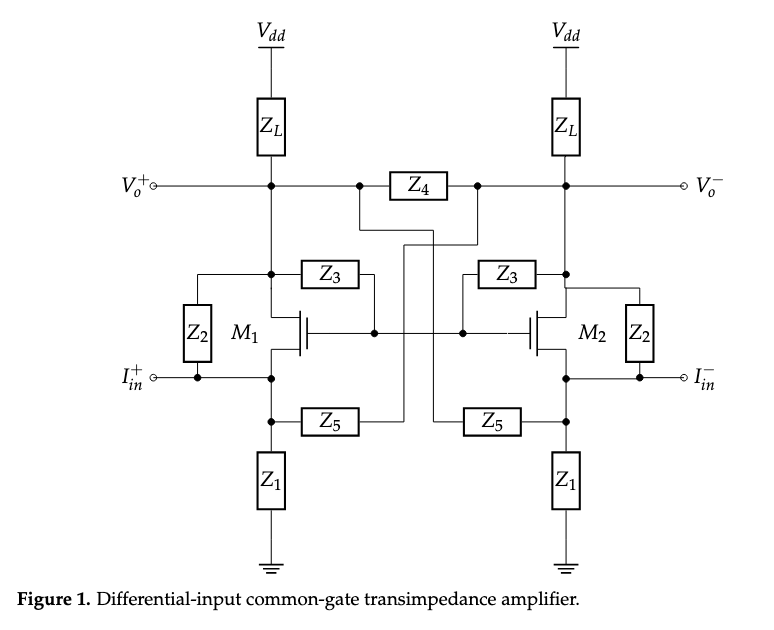

In [73]:
experiment_name = "CG_TIA_Design_Specae_Visualization_Automated_simple"
# experiment_name = "CG_TIA_Design_Specae_Visualization_Automated_some_parasitic" # for BPF-5
path_to_pkl = f"Runs/{experiment_name}/results.pkl"
symbolic_experiment_result = ExperimentResult(experiment_name=experiment_name)
symbolic_experiment_result = symbolic_experiment_result.load(path_to_pkl)

# Problem Setup

## Select a topology to size

In [74]:
# ALLOWED_Z_CONNECTIONS = "Z1_Z5_ZL" # for BPF-3/BPF-4
# ALLOWED_Z_CONNECTIONS = "Z1_Z3_ZL" # for BPF-5
ALLOWED_Z_CONNECTIONS = "Z1_ZL" # for BPF-2
classifications, tf = symbolic_experiment_result.get_impedance_key(ALLOWED_Z_CONNECTIONS)
print(f"{ALLOWED_Z_CONNECTIONS} - count of tfs {len(classifications)}")
tf

Z1_ZL - count of tfs 110


Z_1*Z_L*g_m/(Z_1*g_m + 1)

In [75]:
FILTER_TYPE = "BP" # should switch to using enums
classifications_filtered = symbolic_experiment_result.get_filter_types(fTypes=[FILTER_TYPE], zCombos=ALLOWED_Z_CONNECTIONS)
len(classifications_filtered)

4

In [ ]:
# sel = 2 # BPF-3 (Z1_Z5_ZL)
# sel = 2 # BPF-5 (Z1_Z3_ZL)
sel = 1 # BPF-2 (Z1_ZL)


tf_to_size = classifications_filtered[sel]
print(f"Selected Z-combo is\n{tf_to_size.zCombo}")
print(f"numer order = {tf_to_size.tf_numer_order}\ndenom_order = {tf_to_size.tf_denom_order}\nfilter_id: {tf_to_size.filter_id}")
tf_to_size.transferFunc

Selected Z-combo is
(L_1*s, oo, oo, oo, oo, R_L/(C_L*R_L*s + 1))
numer order = 1
denom_order = 2
filter_id: 6172


L_1*R_L*g_m*s/(C_L*L_1*R_L*g_m*s**2 + s*(C_L*R_L + L_1*g_m) + 1)

### Filter Parameters

In [78]:
print(f"filter parameters are {tf_to_size.parameters.keys()}")

filter parameters are dict_keys(['Q', 'wo', 'bandwidth', 'K_LP', 'K_HP', 'K_BP', 'Qz', 'Wz'])


In [79]:
# Q
tf_to_size.parameters.get("Q", None)

sqrt(C_L)*sqrt(L_1)*sqrt(R_L)*g_m*sqrt(1/g_m)/(C_L*R_L + L_1*g_m)

In [80]:
# WO
tf_to_size.parameters.get("wo", None)

sqrt(1/g_m)/(sqrt(C_L)*sqrt(L_1)*sqrt(R_L))

In [81]:
# bandwidth
tf_to_size.parameters.get("bandwidth", None)

(C_L*R_L + L_1*g_m)/(C_L*L_1*R_L*g_m)

In [82]:
# K_BP
tf_to_size.parameters.get("K_BP", None)

L_1*R_L*g_m/(C_L*R_L + L_1*g_m)

# Design Space Exploration of the Selected Topology

In [83]:
assist = Symbolic_Sizing_Assist(
    filter_classification=tf_to_size
)

In [84]:
assist.get_design_variables()

['g_m', 'L_1', 'R_L', 'C_L']

In [85]:
assist.get_metrics()

['Q', 'wo', 'bandwidth', 'K_BP']

In [86]:
# assist.kill_variable()
RANGE_R = (2e2, 1e4)
RANGE_C = (100e-15, 1e-9)
RANGE_L = (100e-12, 1e-9)

RANGE_GM = (1e-3, 100e-3) # 1mS to 100mS

FIXED_GM = 10e-3  # 10 mS
FIXED_L = 500e-12 # 500 pH

In [87]:
# # BPF-3 (Z1 Z5 ZL)
# exploration = assist.explore_systematically(design_var_limits={
#     "R_5" : RANGE_R,
#     "C_L" : RANGE_C, 
#     "L_1" : RANGE_L,    
#     "g_m" : RANGE_GM
# }, 
# num_points_per_var=10,
# fixed_vars={
# },
# use_log_spacing=True
# )

# # BPF-5 (Z1 Z3 ZL)
# exploration = assist.explore_systematically(design_var_limits={
#     # "r_o" : (1e3, 2e5),
#     "R_1" : RANGE_R, 
#     "C_L" : RANGE_C, 
#     "L_L" : RANGE_L,    
#     "g_m" : RANGE_GM
# }, 
# num_points_per_var=10,
# fixed_vars={
#     "r_o" : 1e5,
#     "C_3" : 100e-15,
# },
# use_log_spacing=True
# )

# BPF-2 (Z1 ZL)
exploration = assist.explore_systematically(design_var_limits={
    # "r_o" : (1e3, 2e5),
    "R_L" : RANGE_R, 
    "C_L" : RANGE_C, 
    "L_1" : RANGE_L,    
    "g_m" : RANGE_GM
}, 
num_points_per_var=10,
fixed_vars={
},
use_log_spacing=True
)

Exploring design space: 100%|█████████████| 10000/10000 [07:34<00:00, 22.02it/s]


In [88]:
exploration.to_dataframe().to_csv("PB_BPF_2_10000points.csv")
# exploration.to_dataframe().to_csv("PB_BPF_3_10000points.csv")
# exploration.to_dataframe().to_csv("PB_BPF_5_10000points.csv")

exploration.to_dataframe()

,x_R_L,x_C_L,x_L_1,x_g_m,Q,wo,bandwidth,K_BP
0,200.0,1.000000e-13,1.000000e-10,0.001000,0.070,7.071068e+11,1.005000e+13,0.995
1,200.0,1.000000e-13,1.000000e-10,0.001668,0.091,5.474871e+11,6.044843e+12,1.654
2,200.0,1.000000e-13,1.000000e-10,0.002783,0.116,4.238994e+11,3.643814e+12,2.744
3,200.0,1.000000e-13,1.000000e-10,0.004642,0.149,3.282099e+11,2.204435e+12,4.536
4,200.0,1.000000e-13,1.000000e-10,0.007743,0.189,2.541210e+11,1.341550e+12,7.454
...,...,...,...,...,...,...,...,...
9995,10000.0,1.000000e-09,1.000000e-09,0.012915,0.001,8.799225e+07,7.742647e+10,0.013
9996,10000.0,1.000000e-09,1.000000e-09,0.021544,0.001,6.812921e+07,4.641599e+10,0.022
9997,10000.0,1.000000e-09,1.000000e-09,0.035938,0.002,5.274997e+07,2.782569e+10,0.036
9998,10000.0,1.000000e-09,1.000000e-09,0.059948,0.002,4.084239e+07,1.668111e+10,0.060


In [90]:
from symxplorer.designer_tools.visualizer import AnalysisSuite

analysis = AnalysisSuite(exploration=exploration)

In [ ]:
analysis.plot_contour(x_param="x_C_L", y_param="x_R_5", metric_name="K_BP")

In [47]:
analysis.plot_sensitivity(metric_name="wo")

In [91]:
analysis.plot_tradeoff(metric1="Q", metric2="K_BP", log_scale_2=True)
analysis.plot_tradeoff(metric1="wo", metric2="K_BP", log_scale_1=True, log_scale_2=True)
analysis.plot_tradeoff(metric1="wo", metric2="bandwidth", log_scale_1=True, log_scale_2=True)

In [25]:
analysis.plot_box(design_var="x_R_5", metric_name="K_BP")

In [ ]:
analysis.plot_distribution(metric_name="K_BP")

In [49]:
analysis.plot_3d_scatter(design_var1="x_C_L", design_var2="x_R_5", metric_name="K_BP")

In [29]:
analysis.plot_progression(metric_name="K_BP")

In [ ]:
analysis.plot_parallel(metrics=["wo"])

# Visualizing the Frequency Response

In [ ]:
sym_vis = Symbolic_Visualizer(filter_classification=tf_to_size)
sym_vis.is_defined_numerically()

In [ ]:
sym_vis.get_parameters()

In [ ]:
sym_vis.set_params(param_str_to_value={
    "R" : 1e3, # used in case of equal R
    "C" : 1e-12, # used in case of equal C
    "R_1" : 1e3,
    "R_2" : 1e3,
    "C_L" : 100e-12,
    "L_L" : 1e-9,
    "g_m" : 20e-3,
})
sym_vis.params_to_value

In [ ]:
magnitude_expr, phase_expr, H_numeric = sym_vis.get_bode_expression()
H_numeric

In [ ]:
expr, val = sym_vis.eval_filter_parameter(param_name="K_BP", num_of_decimals=3)
expr

In [ ]:
sym_vis.print_filter_parameters()
sym_vis.visualize(start_freq_order=8.4, end_freq_order=8.8, num_of_points=200)